In [1]:
import pandas as pd
df=pd.read_csv("ale_d.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,2020/10/12,65.0,72.10,60.00,70.00,59867551
1,2020/10/13,72.0,80.00,71.08,80.00,18452974
2,2020/10/14,84.0,90.30,71.25,75.96,16731591
3,2020/10/15,76.0,80.00,71.52,79.22,6235974
4,2020/10/16,80.0,85.44,79.25,81.45,15480831


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347 entries, 0 to 1346
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1347 non-null   object 
 1   Open    1347 non-null   float64
 2   High    1347 non-null   float64
 3   Low     1347 non-null   float64
 4   Close   1347 non-null   float64
 5   Volume  1347 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 63.3+ KB


In [3]:
close=df["Close"]
close.head()

0    70.00
1    80.00
2    75.96
3    79.22
4    81.45
Name: Close, dtype: float64

In [4]:
Return=df["Close"].pct_change()
Return.describe()

count    1346.000000
mean       -0.000366
std         0.027252
min        -0.137678
25%        -0.015134
50%        -0.000537
75%         0.012722
max         0.157756
Name: Close, dtype: float64

In [5]:
df["Return"]=df["Close"].pct_change()
df.head()

,Date,Open,High,Low,Close,Volume,Return
0,2020/10/12,65.0,72.10,60.00,70.00,59867551,NaN
1,2020/10/13,72.0,80.00,71.08,80.00,18452974,0.142857
2,2020/10/14,84.0,90.30,71.25,75.96,16731591,-0.050500
3,2020/10/15,76.0,80.00,71.52,79.22,6235974,0.042917
4,2020/10/16,80.0,85.44,79.25,81.45,15480831,0.028149


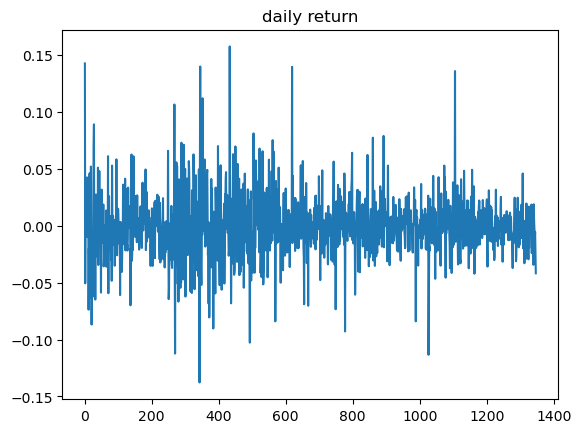

In [6]:
import matplotlib.pyplot as plt
plt.plot(df["Return"])
plt.title("daily return")
plt.show()

In [7]:
df["Cumulative_Return"]=(1+df["Return"]).cumprod()
df["Cumulative_Return"].head()

0         NaN
1    1.142857
2    1.085143
3    1.131714
4    1.163571
Name: Cumulative_Return, dtype: float64

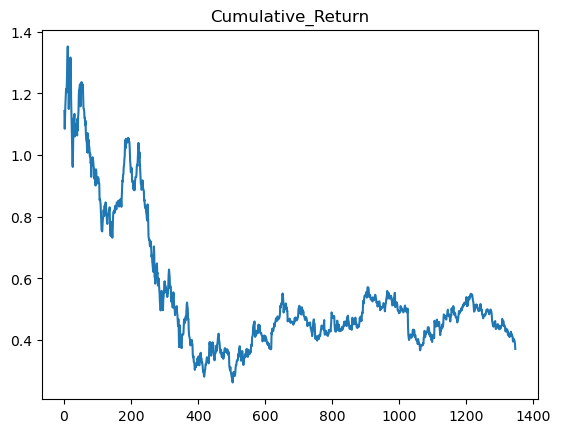

In [8]:
plt.plot(df["Cumulative_Return"])
plt.title("Cumulative_Return")
plt.show()

In [9]:
df["Return"].std()

0.027252241831641752

In [10]:
min_,max_=df["Return"].min() , df["Return"].max()
print(f"最小值:{min_},最大值:{max_}")

最小值:-0.13767760901518866,最大值:0.15775635407537258


In [11]:
df["Rolling"]=df["Return"].rolling(20).std()

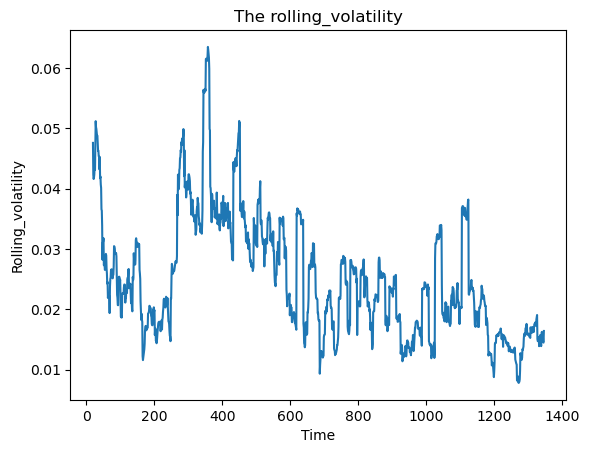

In [12]:
plt.plot(df["Rolling"])
plt.title("The rolling_volatility")
plt.xlabel("Time")
plt.ylabel("Rolling_volatility")
plt.show()

In [13]:
df["Cumulative_Return"].tail()

1342    0.402643
1343    0.398571
1344    0.396500
1345    0.387357
1346    0.371214
Name: Cumulative_Return, dtype: float64

In [14]:
df["Rolling"].max()

0.06351085339949873

In [15]:
current_drawdown=(df["Rolling"].iloc[-1])/(df["Rolling"].max())-1
print(f"当前距离最高值的跌幅:{current_drawdown:.2%}")

当前距离最高值的跌幅:-74.18%


In [16]:
peak_index=df["Rolling"].idxmax()
print(peak_index)

358
